In [6]:
import pickle as pkl

import numpy as np

#### Objective:

Experiment with mapping Vendors and Vectors to the same vector space.

#### Depends on:

In [ ]:
mcc_to_vector_fname = "./data/mcc_to_vector.pkl"
vendor_to_vector_fname = "./data/vendor_to_vector.pkl"

----------------------

In [7]:
with open(mcc_to_vector_fname, "rb") as f:
    mcc_to_vector = pkl.load(f)

with open(vendor_to_vector_fname, "rb") as f:
    vendor_to_vector = pkl.load(f)

In [8]:
mccs_str = sorted(mcc_to_vector.keys())
vendors_str = sorted(vendor_to_vector.keys())

In [9]:
mccs_idx_to_name = {i: name for i, name in enumerate(mccs_str)}
mccs_name_to_idx = {name: i for i, name in enumerate(mccs_str)}

vendors_idx_to_name = {i: name for i, name in enumerate(vendors_str)}
vendors_name_to_idx = {name: i for i, name in enumerate(vendors_str)}

In [10]:
len(vendors_str), len(vendor_to_vector[vendors_str[0]]["mean"])

(81, 768)

In [11]:
len(mccs_str), len(mcc_to_vector[mccs_str[0]]["embedding"])

(434, 768)

In [15]:
source_matrix = np.zeros(
    (len(mccs_str) + len(vendors_str), len(mcc_to_vector[mccs_str[0]]["embedding"]))
)

In [16]:
source_matrix.shape

(515, 768)

In [17]:
for i, mcc_name in enumerate(mccs_str):
    source_matrix[i] = mcc_to_vector[mccs_str[i]]["embedding"]

for i, vendor_name in enumerate(vendors_str):
    source_matrix[len(mccs_str) + i] = vendor_to_vector[vendors_str[i]]["mean"]

In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [20]:
svd = TruncatedSVD(n_components=20, n_iter=1000, random_state=42)

In [21]:
decomposed = svd.fit_transform(source_matrix)

In [37]:
embedded = TSNE(
    n_components=2, learning_rate="auto", init="random", random_state=42, perplexity=20
).fit_transform(decomposed)

In [38]:
%matplotlib widget
import matplotlib
from matplotlib import pyplot as plt

matplotlib.use("nbagg")

/tmp/ipykernel_24371/3370679040.py:5: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed two minor releases later.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("nbagg")


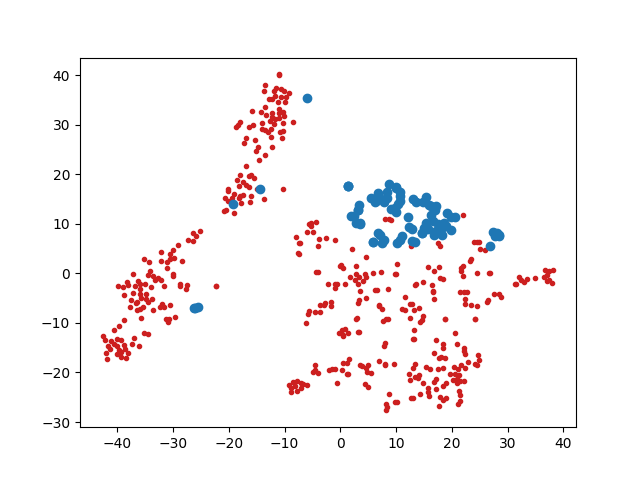

In [40]:
%matplotlib widget
x = embedded[: len(mccs_str), 0]
y = embedded[: len(mccs_str), 1]

fig, ax = plt.subplots()
ax.scatter(x, y, c="#cc1f1f", marker=".")

x = embedded[len(mccs_str) :, 0]
y = embedded[len(mccs_str) :, 1]

ax.scatter(x, y, c="#1f77b4")

x = embedded[:, 0]
y = embedded[:, 1]

# tags = np.array(list(mccs_name_to_idx) + list(vendors_name_to_idx))
# for i, txt in enumerate(tags):
#     ax.annotate(txt, (x[i], y[i]), size=6)

plt.show()